In [1]:
import sys
from pathlib import Path

# Add benchmark-app to the path so we can import bench modules
BENCHMARK_APP_DIR = Path("__file__").resolve().parent.parent
if str(BENCHMARK_APP_DIR) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_APP_DIR))

BASELINES_DIR = BENCHMARK_APP_DIR / "baselines-results"

In [2]:
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from bench.custom_bench.stats import BenchmarkStats, TaskMetadata
from bench.params import QECParams
from constants import (
    DEFAULT_P_LIST,
    DEFAULT_BP_MAX_ITER,
    DEFAULT_MEMBP_MAX_ITER,
    DEFAULT_MEMBP_GAMMA,
    DEFAULT_RELAYBP_PRE_ITER,
    DEFAULT_RELAYBP_MAX_ITER_PER_RELAY,
    DEFAULT_RELAYBP_GAMMA0,
    DEFAULT_RELAYBP_GDI,
    DEFAULT_BPOSD_MAX_ITER,
    DEFAULT_BPOSD_OSD_ORDER,
)

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

## 1. Load Data

In [3]:
DECODER_NAMES = ["BP", "MemBP", "RelayBP", "MWPM", "UnionFind", "BPOSD"]
QEC_PARAMS = [
    QECParams(
        code="RotatedSurfaceCode",
        noise_model="CircuitLevel",
        d=11,
        rounds=11,
        basis="Z",
    ),
    QECParams(
        code="RotatedSurfaceCode",
        noise_model="CircuitLevel",
        d=11,
        rounds=11,
        basis="X",
    ),
    QECParams(
        code="BB_144_12_12",
        noise_model="CircuitLevel",
        d=12,
        rounds=12,
        basis="Z",
    ),
    QECParams(
        code="BB_144_12_12",
        noise_model="CircuitLevel",
        d=12,
        rounds=12,
        basis="X",
    ),
]

In [4]:
def _keep_stats(s: BenchmarkStats) -> bool:
    m = s.metadata
    dp = m.decoder_params
    qec = QECParams(
        code=m.code, noise_model=m.noise_model, d=m.d, rounds=m.rounds, basis=m.basis
    )

    if qec not in QEC_PARAMS:
        return False
    if m.p not in DEFAULT_P_LIST:
        return False

    if m.decoder_name == "BP":
        return dp["max_iter"] == DEFAULT_BP_MAX_ITER
    elif m.decoder_name == "MemBP":
        return (
            dp["max_iter"] == DEFAULT_MEMBP_MAX_ITER
            and dp["gamma"] == DEFAULT_MEMBP_GAMMA[qec]
        )
    elif m.decoder_name == "RelayBP":
        return (
            dp["pre_iter"] == DEFAULT_RELAYBP_PRE_ITER
            and dp["max_iter_per_relay"] == DEFAULT_RELAYBP_MAX_ITER_PER_RELAY
            and dp["gamma0"] == DEFAULT_RELAYBP_GAMMA0[qec]
            and tuple(dp["gamma_dist_interval"]) == DEFAULT_RELAYBP_GDI[qec]
        )
    elif m.decoder_name == "BPOSD":
        return (
            dp["max_bp_iter"] == DEFAULT_BPOSD_MAX_ITER
            and dp["osd_method"] == "OSD_CS"
            and dp["osd_order"] == DEFAULT_BPOSD_OSD_ORDER
        )
    else:
        return True


def load_all_stats() -> list[BenchmarkStats]:
    """Load all custom_benchmark.csv files, filtered to default decoder params."""
    all_stats: list[BenchmarkStats] = []
    for csv_path in sorted(BASELINES_DIR.rglob("custom_benchmark.csv")):
        decoder = csv_path.parent.name
        if decoder not in DECODER_NAMES:
            continue
        stats = BenchmarkStats.load_csv(csv_path)
        for s in stats:
            if _keep_stats(s):
                all_stats.append(s)
    return all_stats


all_stats = load_all_stats()
print(f"Loaded {len(all_stats)} benchmark entries")

Loaded 277 benchmark entries


## 2. Build a DataFrame for easier filtering

In [5]:
def _make_decoder_label(m: TaskMetadata) -> str:
    """Create a display label for a decoder, grouping RelayBP by its parameters."""
    if m.decoder_name == "RelayBP":
        dp = m.decoder_params
        # num_indep_decoders = dp["num_indep_decoders"]
        # stop_nconv = dp["stop_nconv"]
        num_relays = dp["num_relays"]
        # return f"RelayBP (N={num_indep_decoders:2d}, S={stop_nconv}, R={num_relays:2d})"
        return f"RelayBP(R={num_relays})"
    return m.decoder_name


def stats_to_dataframe(stats_list: list[BenchmarkStats]) -> pd.DataFrame:
    """Convert list of BenchmarkStats to a pandas DataFrame."""
    rows = []
    for s in stats_list:
        m = s.metadata
        row = {
            "code": m.code,
            "noise_model": m.noise_model,
            "d": m.d,
            "rounds": m.rounds,
            "basis": m.basis,
            "p": m.p,
            "decoder_name": m.decoder_name,
            # <<< RelayBP-specific columns
            "num_relays": m.decoder_params["num_relays"]
            if m.decoder_name == "RelayBP"
            else pd.NA,
            "stop_nconv": m.decoder_params["stop_nconv"]
            if m.decoder_name == "RelayBP"
            else pd.NA,
            "num_indep_decoders": m.decoder_params["num_indep_decoders"]
            if m.decoder_name == "RelayBP"
            else pd.NA,
            # >>>
            "decoder_label": _make_decoder_label(m),
            "shots": s.shots,
            "FR": s.failure_rate,
            # "LER": s.logical_error_rate,
            # "SMR": s.syndrome_mismatch_rate,
            # <<< Iterative decoder-specific columns
            "avg_iters": s.avg_iters if m.is_iterative else pd.NA,
            # >>>
        }
        rows.append(row)
    return pd.DataFrame(rows)


df = stats_to_dataframe(all_stats)

In [6]:
from IPython.display import display, HTML

# Set options to ensure all data is rendered in the HTML string
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Display within a scrollable div
display(
    HTML(
        f"<div style='height: 300px; overflow: auto; width: fit-content'>{df.to_html()}</div>"
    )
)

,code,noise_model,d,rounds,basis,p,decoder_name,num_relays,stop_nconv,num_indep_decoders,decoder_label,shots,FR,avg_iters
0,BB_144_12_12,CircuitLevel,12,12,X,0.002,BP,<NA>,<NA>,<NA>,BP,6688,0.070275,18.265102
1,BB_144_12_12,CircuitLevel,12,12,X,0.003,BP,<NA>,<NA>,<NA>,BP,5376,0.231585,28.856027
2,BB_144_12_12,CircuitLevel,12,12,X,0.004,BP,<NA>,<NA>,<NA>,BP,2944,0.507133,39.066236
3,BB_144_12_12,CircuitLevel,12,12,X,0.005,BP,<NA>,<NA>,<NA>,BP,3072,0.786458,46.171875
4,BB_144_12_12,CircuitLevel,12,12,X,0.002,BPOSD,<NA>,<NA>,<NA>,BPOSD,590848,0.000169,<NA>
5,BB_144_12_12,CircuitLevel,12,12,X,0.003,BPOSD,<NA>,<NA>,<NA>,BPOSD,42560,0.002467,<NA>
6,BB_144_12_12,CircuitLevel,12,12,X,0.004,BPOSD,<NA>,<NA>,<NA>,BPOSD,4512,0.030142,<NA>
7,BB_144_12_12,CircuitLevel,12,12,X,0.005,BPOSD,<NA>,<NA>,<NA>,BPOSD,1824,0.144737,<NA>
8,BB_144_12_12,CircuitLevel,12,12,X,0.002,MemBP,<NA>,<NA>,<NA>,MemBP,23808,0.006300,10.081947
9,BB_144_12_12,CircuitLevel,12,12,X,0.003,MemBP,<NA>,<NA>,<NA>,MemBP,8256,0.045179,15.863735


## 3. Helper: Wilson Confidence Interval

In [7]:
def _wilson_ci(p_hat: float, n: int, *, z: float = 1.96) -> tuple[float, float]:
    """Compute the Wilson score confidence interval for a binomial distribution.

    Parameters
    ----------
    p_hat : float
        Observed fraction of successes.
    n : int
        Number of trials.
    z : float
        Number of standard deviations for the interval (default 1.96 for ~95% confidence level).

    Returns
    -------
    tuple[float, float]
        Lower and upper bounds of the confidence interval.
    """
    if n == 0:
        return (0.0, 1.0)
    z2 = z * z
    denom = 1 + z2 / n
    centre = (p_hat + z2 / (2 * n)) / denom
    half_width = z * np.sqrt(p_hat * (1 - p_hat) / n + z2 / (4 * n**2)) / denom
    return (max(centre - half_width, 0.0), min(centre + half_width, 1.0))

## 4. Failure Rate (FR) vs PER

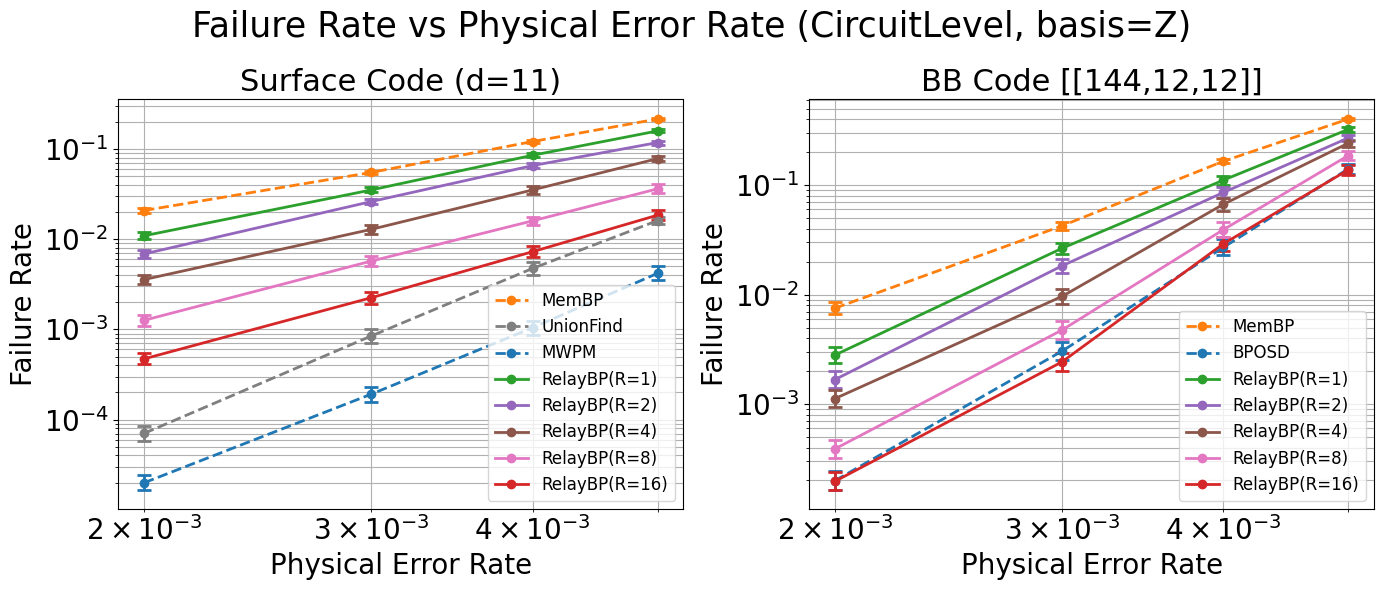

In [8]:
def plot_fr_vs_per(
    *, noise_model: str, basis: str, stop_nconv: int, num_indep_decoders: int
):
    cond_rsc = (
        (df["code"] == "RotatedSurfaceCode")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 11)
        & (df["rounds"] == 11)
        & (df["basis"] == basis)
    )
    cond_bb = (
        (df["code"] == "BB_144_12_12")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 12)
        & (df["rounds"] == 12)
        & (df["basis"] == basis)
    )
    cond_dec = (
        (df["decoder_name"] == "MemBP")
        | (df["decoder_name"] == "MWPM")
        | (df["decoder_name"] == "UnionFind")
        | (df["decoder_name"] == "BPOSD")
        | (
            (df["decoder_name"] == "RelayBP")
            & (df["stop_nconv"] == stop_nconv)
            & (df["num_indep_decoders"] == num_indep_decoders)
        )
    )
    filtered_df = df[(cond_rsc | cond_bb) & cond_dec]

    all_codes = ["RotatedSurfaceCode", "BB_144_12_12"]
    code_to_label = {
        "BB_144_12_12": "BB Code [[144,12,12]]",
        "RotatedSurfaceCode": "Surface Code (d=11)",
    }
    ncols = len(all_codes)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    ax: Axes
    for ax, code in zip(axes, all_codes):
        sub = filtered_df[filtered_df["code"] == code]
        legend_entries = []
        for label, grp in sub.groupby("decoder_label"):
            grp = grp.sort_values("p")
            ps = grp["p"].values
            rates = grp["FR"].values
            shots = grp["shots"].values
            err_lo: list[float] = []
            err_hi: list[float] = []
            for rate, n in zip(rates, shots):
                lb, ub = _wilson_ci(float(rate), int(n))
                err_lo.append(rate - lb)
                err_hi.append(ub - rate)
            is_relaybp = grp["decoder_name"].iloc[0] == "RelayBP"
            eb = ax.errorbar(
                ps,
                rates,
                yerr=[err_lo, err_hi],
                label=label,
                marker="o",
                linestyle="-" if is_relaybp else "--",
                capsize=5,
                capthick=2,
                linewidth=2,
                elinewidth=2,
            )
            line = eb.lines[0]
            legend_entries.append(
                (line, label, (int(is_relaybp), -rates[0]))
            )  # last element is used for legend sorting
        legend_entries.sort(key=lambda t: t[2])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Physical Error Rate", fontsize=20)
        ax.set_ylabel("Failure Rate", fontsize=20)
        ax.tick_params(axis="x", which="minor", labelsize=20)
        ax.tick_params(axis="y", labelsize=20)
        ax.set_title(f"{code_to_label[code]}", fontsize=22)
        ax.legend(
            [h for h, _, _ in legend_entries],
            [lab for _, lab, _ in legend_entries],
            fontsize=12,
        )
        ax.grid(True, which="both")

    fig.suptitle(
        f"Failure Rate vs Physical Error Rate ({noise_model}, basis={basis})",
        fontsize=25,
    )
    fig.tight_layout()

    plt.savefig("FR_vs_PER.pdf")
    plt.show()


plot_fr_vs_per(
    noise_model="CircuitLevel", basis="Z", stop_nconv=1, num_indep_decoders=1
)

## 5. Average Iterations vs PER

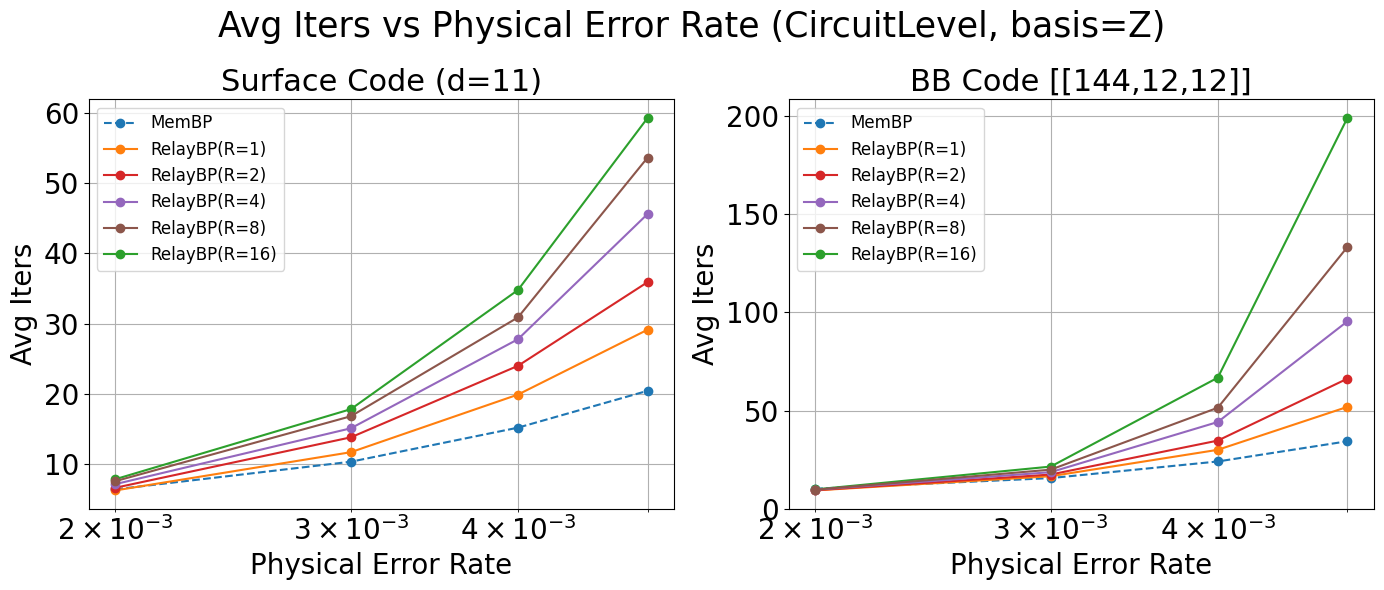

In [9]:
def plot_avg_iters_vs_per(
    *, noise_model: str, basis: str, stop_nconv: int, num_indep_decoders: int
):
    cond_rsc = (
        (df["code"] == "RotatedSurfaceCode")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 11)
        & (df["rounds"] == 11)
        & (df["basis"] == basis)
    )
    cond_bb = (
        (df["code"] == "BB_144_12_12")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 12)
        & (df["rounds"] == 12)
        & (df["basis"] == basis)
    )
    cond_dec = (df["decoder_name"] == "MemBP") | (
        (df["decoder_name"] == "RelayBP")
        & (df["stop_nconv"] == stop_nconv)
        & (df["num_indep_decoders"] == num_indep_decoders)
    )
    filtered_df = df[(cond_rsc | cond_bb) & cond_dec]

    all_codes = ["RotatedSurfaceCode", "BB_144_12_12"]
    code_to_label = {
        "BB_144_12_12": "BB Code [[144,12,12]]",
        "RotatedSurfaceCode": "Surface Code (d=11)",
    }
    ncols = len(all_codes)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    ax: Axes
    for ax, code in zip(axes, all_codes):
        sub = filtered_df[filtered_df["code"] == code]
        legend_entries = []
        for label, grp in sub.groupby("decoder_label"):
            grp = grp.sort_values("p")
            ps = grp["p"].values
            avg_iters = grp["avg_iters"].values
            is_relaybp = grp["decoder_name"].iloc[0] == "RelayBP"
            (line,) = ax.plot(
                ps,
                avg_iters,
                label=label,
                marker="o",
                linestyle="-" if is_relaybp else "--",
            )
            legend_entries.append(
                (line, label, (int(is_relaybp), avg_iters[-1]))
            )  # last element is used for legend sorting
        legend_entries.sort(key=lambda t: t[2])
        ax.set_xscale("log")
        # ax.set_yscale("log")
        ax.set_xlabel("Physical Error Rate", fontsize=20)
        ax.set_ylabel("Avg Iters", fontsize=20)
        ax.tick_params(axis="x", which="minor", labelsize=20)
        ax.tick_params(axis="y", labelsize=20)
        ax.set_title(f"{code_to_label[code]}", fontsize=22)
        ax.legend(
            [h for h, _, _ in legend_entries],
            [lab for _, lab, _ in legend_entries],
            fontsize=12,
        )
        ax.grid(True, which="both")

    fig.suptitle(
        f"Avg Iters vs Physical Error Rate ({noise_model}, basis={basis})",
        fontsize=25,
    )
    fig.tight_layout()

    plt.savefig("avg_iters_vs_PER.pdf")
    plt.show()


plot_avg_iters_vs_per(
    noise_model="CircuitLevel", basis="Z", stop_nconv=1, num_indep_decoders=1
)

## 6. Compare RelayBP with different parameters -- BB_144_12_12, CircuitLevel, basis=Z

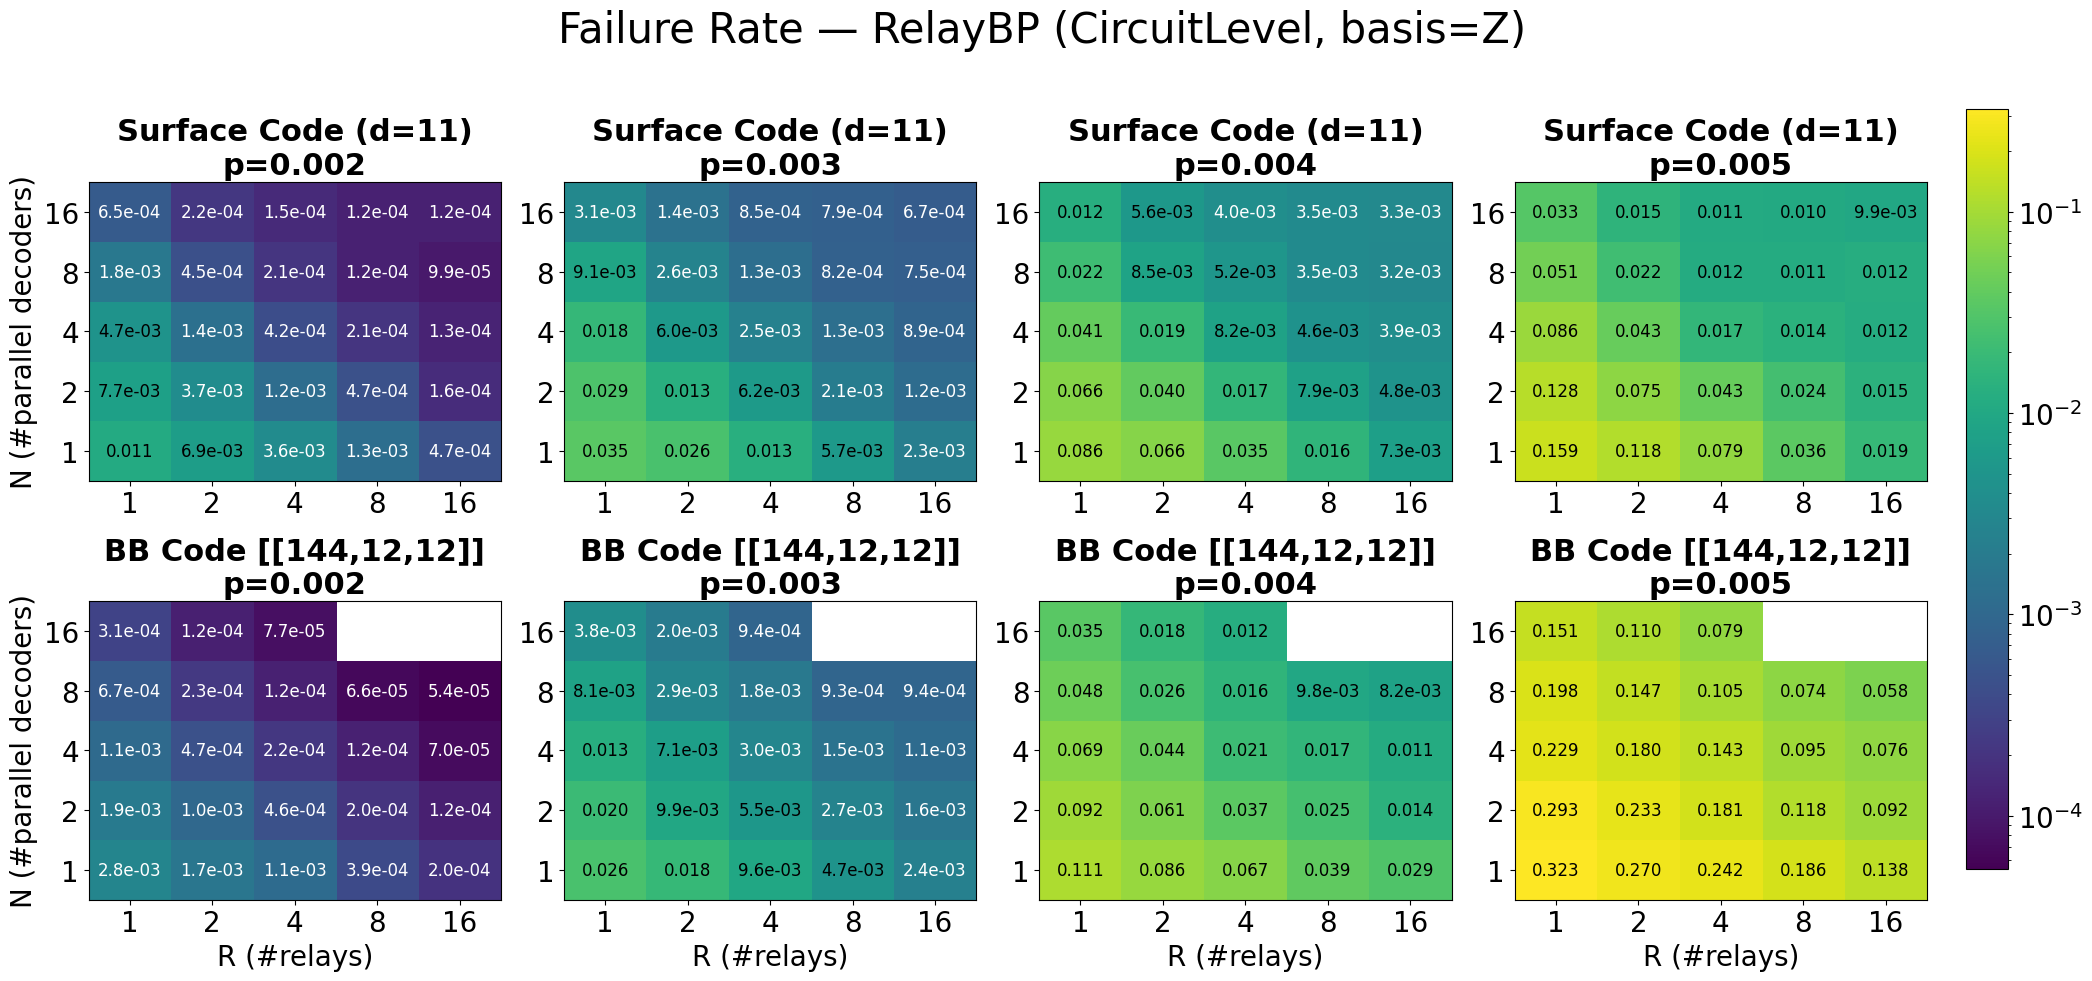

In [10]:
def plot_fr_heatmap_relaybp(
    *,
    noise_model: str,
    basis: str,
    p_list: list[float],
    stop_nconv: int,
    annotations: bool,
):
    cond_rsc = (
        (df["code"] == "RotatedSurfaceCode")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 11)
        & (df["rounds"] == 11)
        & (df["basis"] == basis)
    )
    cond_bb = (
        (df["code"] == "BB_144_12_12")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 12)
        & (df["rounds"] == 12)
        & (df["basis"] == basis)
    )
    cond_dec = (df["decoder_name"] == "RelayBP") & (df["stop_nconv"] == stop_nconv)
    filtered_df = df[(cond_rsc | cond_bb) & cond_dec]

    all_codes = ["RotatedSurfaceCode", "BB_144_12_12"]
    code_to_label = {
        "BB_144_12_12": "BB Code [[144,12,12]]",
        "RotatedSurfaceCode": "Surface Code (d=11)",
    }

    all_num_relays = sorted(filtered_df["num_relays"].unique().astype(int))
    all_num_indep_decoders = sorted(
        filtered_df["num_indep_decoders"].unique().astype(int)
    )
    vmin = filtered_df["FR"].min()
    vmax = filtered_df["FR"].max()
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # row: code, column: p
    nrows, ncols = len(all_codes), len(p_list)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols + 1, 5 * nrows),
        squeeze=False,
    )
    cmap = plt.cm.viridis.copy()
    cmap.set_bad("white")

    for i, code in enumerate(all_codes):
        for j, p in enumerate(p_list):
            ax: Axes = axes[i][j]
            sub = filtered_df[(filtered_df["code"] == code) & (filtered_df["p"] == p)]

            # Build 2D grid, horizontal: num_relays, vertical: num_indep_decoders
            grid = np.full((len(all_num_indep_decoders), len(all_num_relays)), np.nan)
            for _, row in sub.iterrows():
                yi = all_num_indep_decoders.index(int(row["num_indep_decoders"]))
                xi = all_num_relays.index(int(row["num_relays"]))
                grid[yi, xi] = row["FR"]

            im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto", origin="lower")

            # Annotations
            if annotations:
                for yi in range(len(all_num_indep_decoders)):
                    for xi in range(len(all_num_relays)):
                        val = grid[yi, xi]
                        if np.isnan(val):
                            continue
                        txt = f"{val:.3f}" if val >= 0.01 else f"{val:.1e}"
                        color = "white" if val < np.sqrt(vmin * vmax) else "black"
                        ax.text(
                            xi,
                            yi,
                            txt,
                            ha="center",
                            va="center",
                            fontsize=12,
                            color=color,
                        )

            # Tick labels
            ax.set_xticks(range(len(all_num_relays)))
            ax.set_xticklabels(all_num_relays)
            ax.set_yticks(range(len(all_num_indep_decoders)))
            ax.set_yticklabels(all_num_indep_decoders)
            ax.tick_params(axis="both", labelsize=20)

            # Grid title
            ax.set_title(
                f"{code_to_label[code]}\np={p}", fontsize=22, fontweight="bold"
            )

            # Y label (left column only)
            if j == 0:
                ax.set_ylabel("N (#parallel decoders)", fontsize=20)
            else:
                ax.set_ylabel("")

            # X label (bottom row only)
            if i == nrows - 1:
                ax.set_xlabel("R (#relays)", fontsize=20)
            else:
                ax.set_xlabel("")

    fig.suptitle(
        f"Failure Rate — RelayBP ({noise_model}, basis={basis})",
        fontsize=30,
    )
    fig.tight_layout(rect=[0, 0, 0.93, 0.95])

    # Add colorbar in a dedicated axes to the right of the subplots
    cbar_ax: Axes = fig.add_axes([0.94, 0.12, 0.02, 0.76])
    cbar_ax.tick_params(labelsize=20)
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("FR_heatmap_relaybp.pdf")
    plt.show()


plot_fr_heatmap_relaybp(
    noise_model="CircuitLevel",
    basis="Z",
    p_list=DEFAULT_P_LIST,
    stop_nconv=1,
    annotations=True,
)

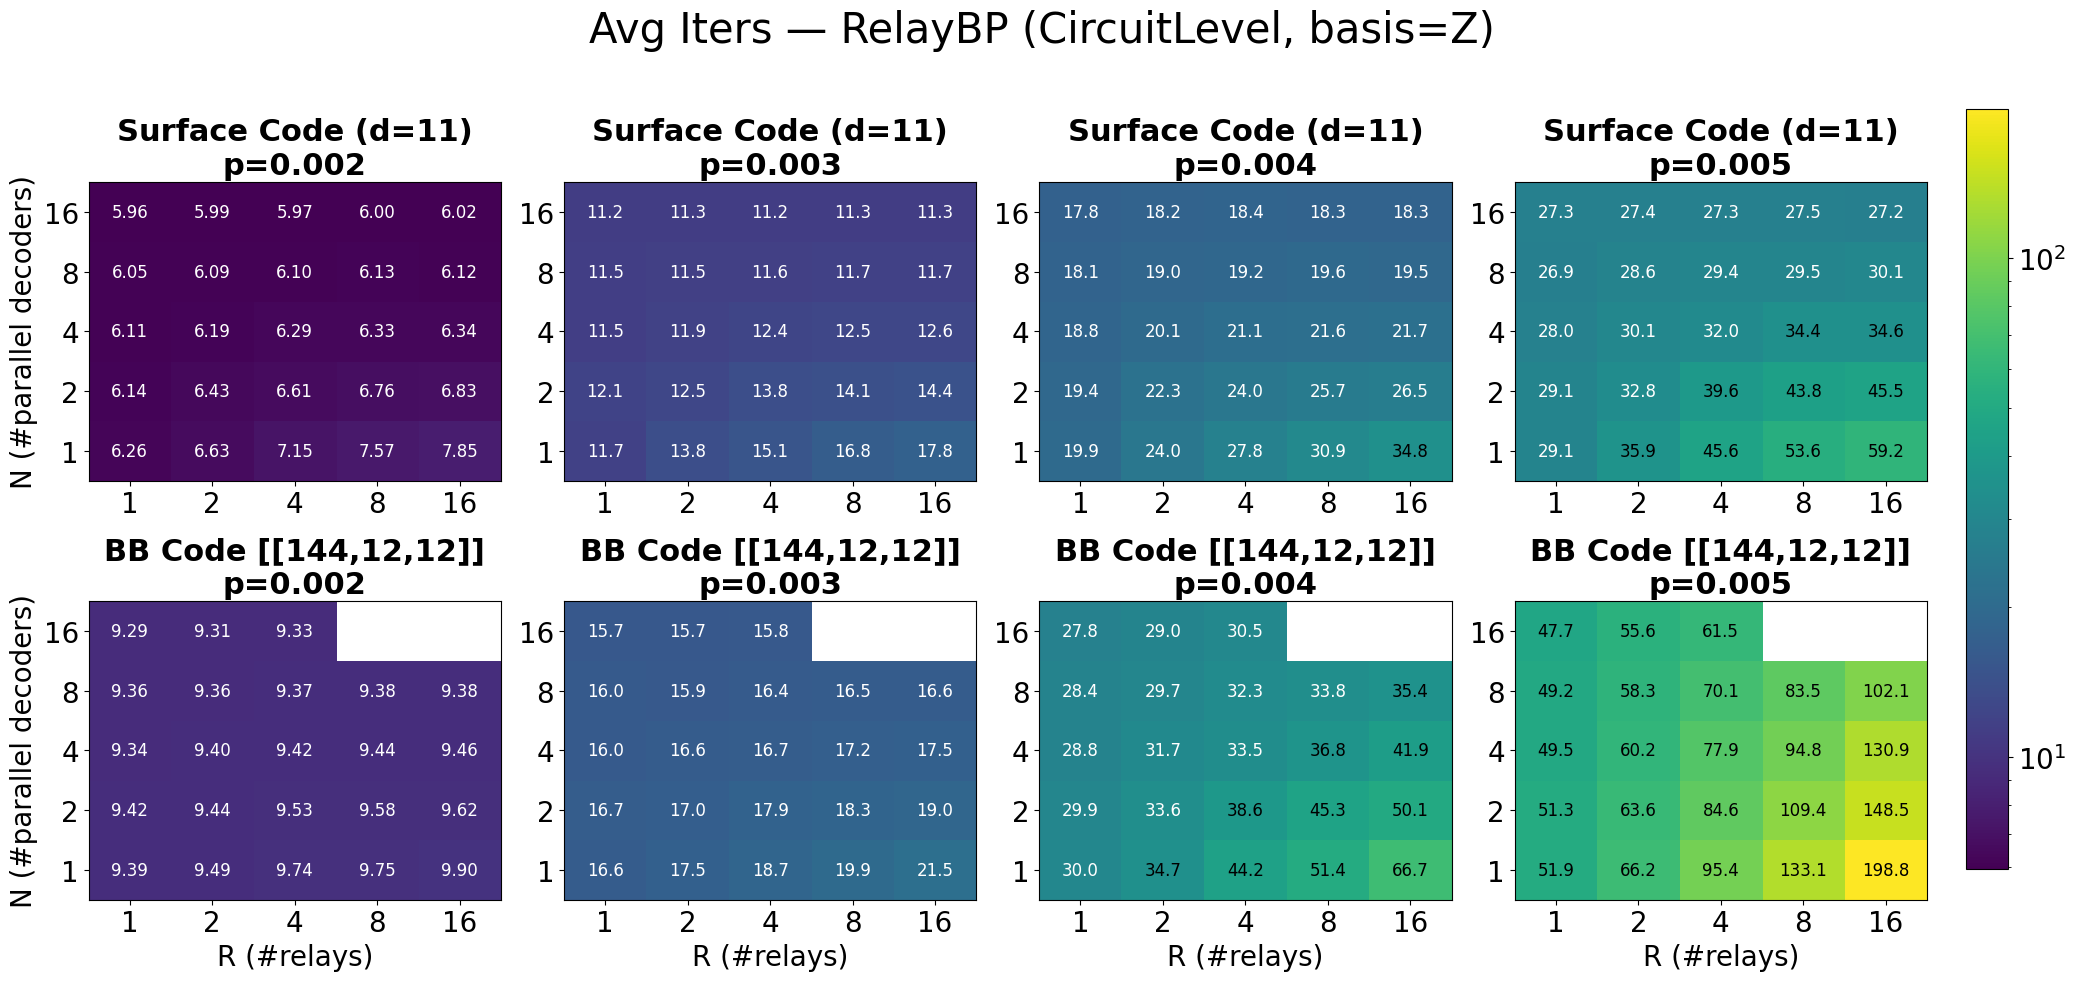

In [11]:
def plot_avg_iters_heatmap_relaybp(
    *,
    noise_model: str,
    basis: str,
    p_list: list[float],
    stop_nconv: int,
    annotations: bool,
):
    cond_rsc = (
        (df["code"] == "RotatedSurfaceCode")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 11)
        & (df["rounds"] == 11)
        & (df["basis"] == basis)
    )
    cond_bb = (
        (df["code"] == "BB_144_12_12")
        & (df["noise_model"] == noise_model)
        & (df["d"] == 12)
        & (df["rounds"] == 12)
        & (df["basis"] == basis)
    )
    cond_dec = (df["decoder_name"] == "RelayBP") & (df["stop_nconv"] == stop_nconv)
    filtered_df = df[(cond_rsc | cond_bb) & cond_dec]

    all_codes = ["RotatedSurfaceCode", "BB_144_12_12"]
    code_to_label = {
        "BB_144_12_12": "BB Code [[144,12,12]]",
        "RotatedSurfaceCode": "Surface Code (d=11)",
    }

    all_num_relays = sorted(filtered_df["num_relays"].unique().astype(int))
    all_num_indep_decoders = sorted(
        filtered_df["num_indep_decoders"].unique().astype(int)
    )
    vmin = filtered_df["avg_iters"].min()
    vmax = filtered_df["avg_iters"].max()
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # row: code, column: p
    nrows, ncols = len(all_codes), len(p_list)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols + 1, 5 * nrows),
        squeeze=False,
    )
    cmap = plt.cm.viridis.copy()
    cmap.set_bad("white")

    for i, code in enumerate(all_codes):
        for j, p in enumerate(p_list):
            ax: Axes = axes[i][j]
            sub = filtered_df[(filtered_df["code"] == code) & (filtered_df["p"] == p)]

            # Build 2D grid, horizontal: num_relays, vertical: num_indep_decoders
            grid = np.full((len(all_num_indep_decoders), len(all_num_relays)), np.nan)
            for _, row in sub.iterrows():
                yi = all_num_indep_decoders.index(int(row["num_indep_decoders"]))
                xi = all_num_relays.index(int(row["num_relays"]))
                grid[yi, xi] = row["avg_iters"]

            im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto", origin="lower")

            # Annotations
            if annotations:
                for yi in range(len(all_num_indep_decoders)):
                    for xi in range(len(all_num_relays)):
                        val = grid[yi, xi]
                        if np.isnan(val):
                            continue
                        txt = f"{val:.2f}" if val < 10 else f"{val:.1f}"
                        color = "white" if val < np.sqrt(vmin * vmax) else "black"
                        ax.text(
                            xi,
                            yi,
                            txt,
                            ha="center",
                            va="center",
                            fontsize=12,
                            color=color,
                        )

            # Tick labels
            ax.set_xticks(range(len(all_num_relays)))
            ax.set_xticklabels(all_num_relays)
            ax.set_yticks(range(len(all_num_indep_decoders)))
            ax.set_yticklabels(all_num_indep_decoders)
            ax.tick_params(axis="both", labelsize=20)

            # Grid title
            ax.set_title(
                f"{code_to_label[code]}\np={p}", fontsize=22, fontweight="bold"
            )

            # Y label (left column only)
            if j == 0:
                ax.set_ylabel("N (#parallel decoders)", fontsize=20)
            else:
                ax.set_ylabel("")

            # X label (bottom row only)
            if i == nrows - 1:
                ax.set_xlabel("R (#relays)", fontsize=20)
            else:
                ax.set_xlabel("")

    fig.suptitle(
        f"Avg Iters — RelayBP ({noise_model}, basis={basis})",
        fontsize=30,
    )
    fig.tight_layout(rect=[0, 0, 0.93, 0.95])

    # Add colorbar in a dedicated axes to the right of the subplots
    cbar_ax: Axes = fig.add_axes([0.94, 0.12, 0.02, 0.76])
    cbar_ax.tick_params(labelsize=20)
    fig.colorbar(im, cax=cbar_ax)

    plt.savefig("avg_iters_heatmap_relaybp.pdf")
    plt.show()


plot_avg_iters_heatmap_relaybp(
    noise_model="CircuitLevel",
    basis="Z",
    p_list=DEFAULT_P_LIST,
    stop_nconv=1,
    annotations=True,
)

## 7. Ridgeline plot of iteration distributions

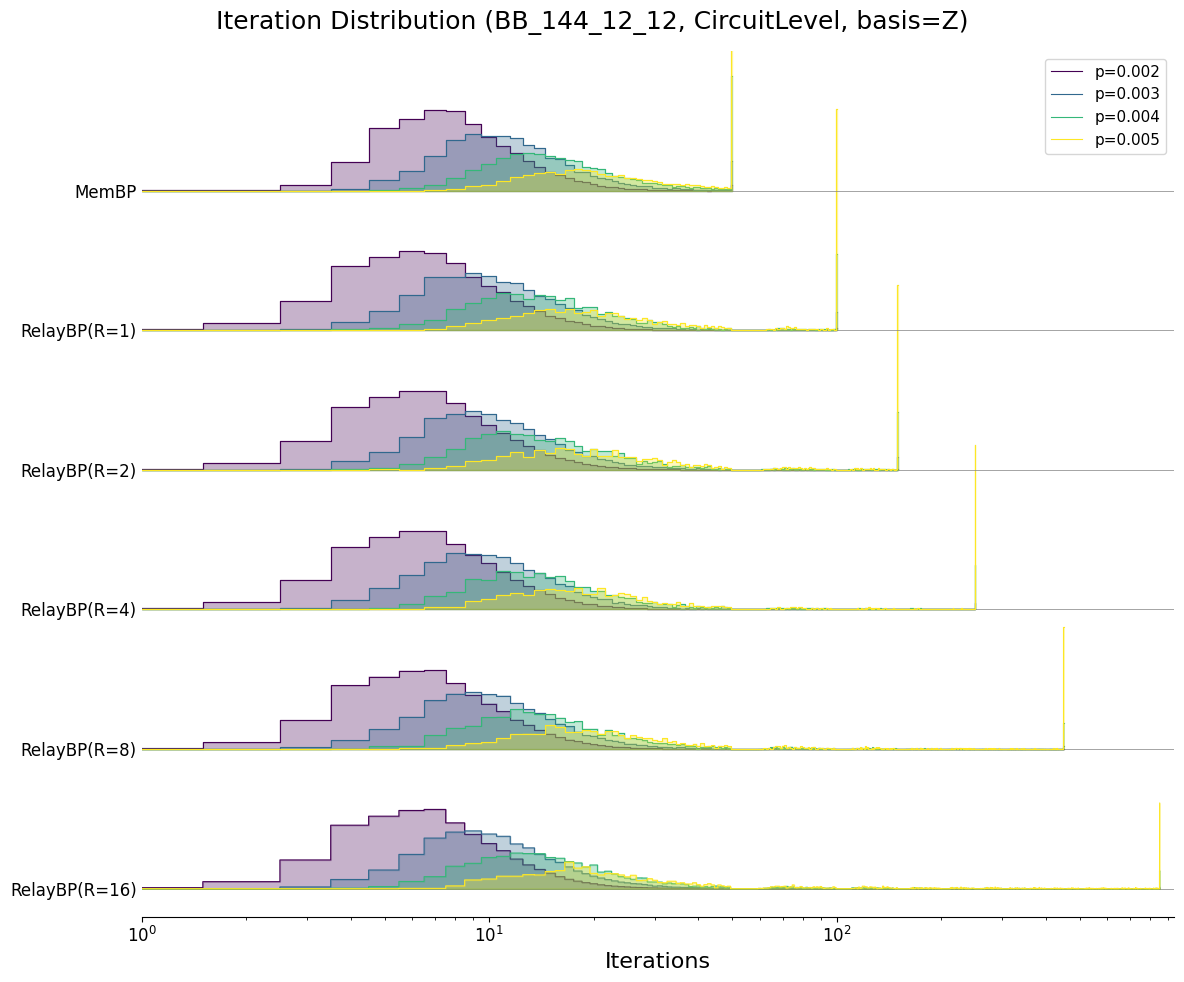

In [12]:
def plot_iter_dist_ridgeline(
    *,
    qec_params: QECParams,
    p_list: list[float],
    num_relays_list: list[int],
    stop_nconv: int,
    num_indep_decoders: int,
):
    # 1. Collect probability mass functions: {(decoder_label, p): pmf_array}
    pmf_data: dict[tuple[str, float], np.ndarray] = {}

    for s in all_stats:
        m = s.metadata
        if not (
            m.code == qec_params.code
            and m.noise_model == qec_params.noise_model
            and m.d == qec_params.d
            and m.rounds == qec_params.rounds
            and m.basis == qec_params.basis
            and m.p in p_list
        ):
            continue

        if m.decoder_name == "MemBP":
            decoder_label = "MemBP"
        elif m.decoder_name == "RelayBP":
            dp = m.decoder_params
            if not (
                dp["stop_nconv"] == stop_nconv
                and dp["num_indep_decoders"] == num_indep_decoders
                and dp["num_relays"] in num_relays_list
            ):
                continue
            decoder_label = f"RelayBP(R={dp['num_relays']})"
        else:
            continue

        # Include unconverged shots at the max_iter bin
        hist = s.iters_hist_on_converged.copy()
        hist[-1] += s.shots - s.synd_matches
        assert int(np.sum(hist)) == s.shots
        assert s.shots > 0

        # Normalize to PMF
        pmf_data[(decoder_label, m.p)] = hist / np.sum(hist)

    # 2. Decoder order (bottom to top)
    decoder_order = [f"RelayBP(R={r})" for r in reversed(num_relays_list)] + ["MemBP"]
    n_decoders = len(decoder_order)

    # 3. Find global max_iter for shared x-axis range
    global_max_iter = max(len(h) - 1 for h in pmf_data.values())

    # 4. Find global max PMF value for consistent y-scaling across all rows
    global_max_pmf = max(h.max() for h in pmf_data.values())

    # 5. Plot
    spacing = 0.2  # vertical spacing between rows
    scale = 2 * spacing  # max curve height

    fig, ax = plt.subplots(figsize=(12, 1.5 * n_decoders + 1))

    # Colors for p values
    cmap = plt.cm.viridis
    colors = [cmap(i / max(len(p_list) - 1, 1)) for i in range(len(p_list))]

    for i, decoder_label in enumerate(decoder_order):
        baseline = i * spacing

        for p_idx, p in enumerate(p_list):
            key = (decoder_label, p)
            if key not in pmf_data:
                continue
            pmf = pmf_data[key]
            max_iter = len(pmf) - 1
            iters = np.arange(1, max_iter + 1)
            values = pmf[1:]

            # Scale consistently: global_max_pmf -> scale height
            scaled = values / global_max_pmf * scale

            color = colors[p_idx]
            ax.fill_between(
                iters,
                baseline,
                baseline + scaled,
                alpha=0.3,
                color=color,
                step="mid",
                zorder=i + 1,
            )
            ax.step(
                iters,
                baseline + scaled,
                where="mid",
                color=color,
                linewidth=0.8,
                zorder=i + 1,
                label=f"p={p}" if i == 0 else None,
            )

        # Baseline line
        ax.axhline(baseline, color="grey", linewidth=0.5, zorder=i + 0.5)

    ax.set_xscale("log")
    ax.set_xlim(1, global_max_iter * 1.1)

    # Y-axis: decoder labels at each baseline
    ax.set_yticks([i * spacing for i in range(n_decoders)])
    ax.set_yticklabels(decoder_order, fontsize=12)
    ax.set_ylim(-0.2 * spacing, (n_decoders - 1) * spacing + spacing)

    ax.set_xlabel("Iterations", fontsize=16)
    ax.legend(fontsize=11, loc="upper right")

    # Minimal spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=12)

    code_label = qec_params.code
    fig.suptitle(
        f"Iteration Distribution ({code_label}, {qec_params.noise_model}, basis={qec_params.basis})",
        fontsize=18,
    )
    fig.tight_layout()

    plt.savefig("iter_dist_ridgeline.pdf")
    plt.show()


plot_iter_dist_ridgeline(
    qec_params=QECParams(
        code="BB_144_12_12",
        noise_model="CircuitLevel",
        d=12,
        rounds=12,
        basis="Z",
    ),
    p_list=DEFAULT_P_LIST,
    num_relays_list=[1, 2, 4, 8, 16],
    stop_nconv=1,
    num_indep_decoders=1,
)

## 8. Cumulative distribution of iterations

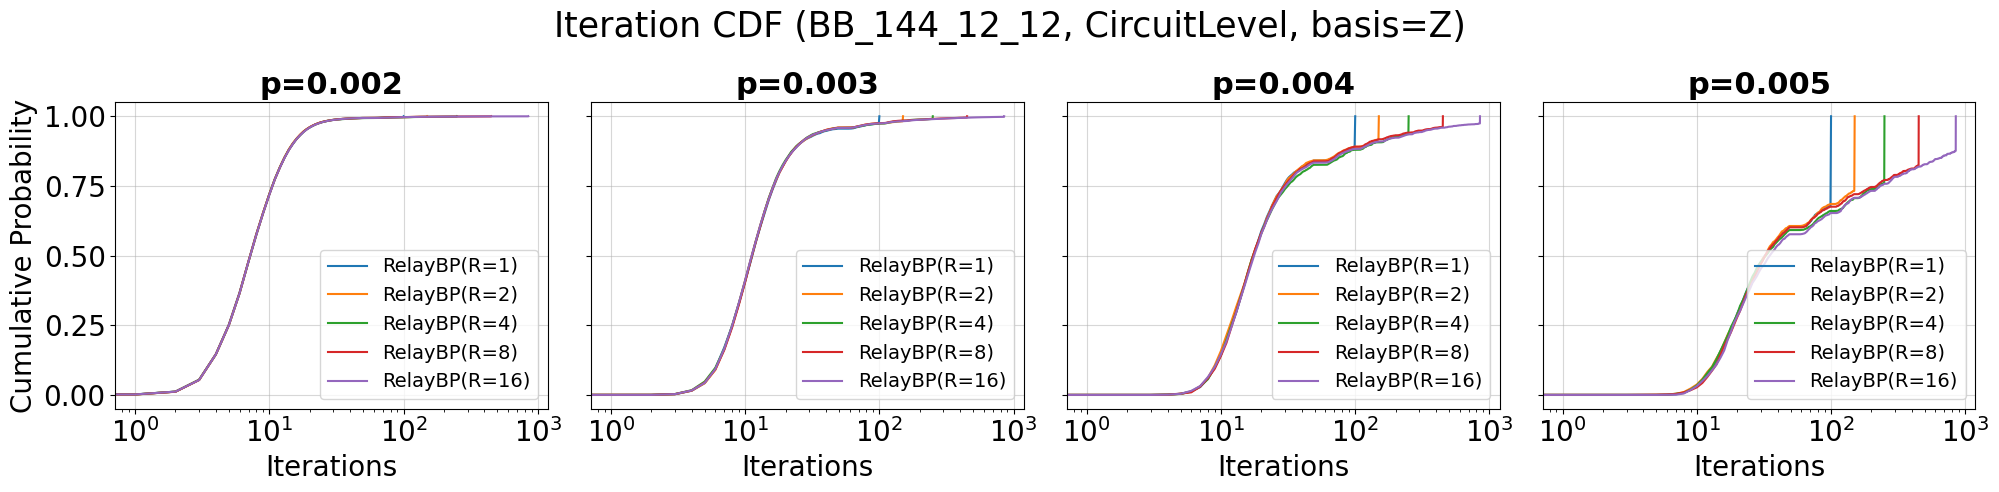

In [13]:
def plot_iter_cdf(
    *,
    qec_params: QECParams,
    p_list: list[float],
    num_relays_list: list[int],
    stop_nconv: int,
    num_indep_decoders: int,
):
    all_decoder_labels = [f"RelayBP(R={r})" for r in num_relays_list]
    # 1. Collect CDFs: {(decoder_label, p): cdf_array}
    cdf_data: dict[tuple[str, float], np.ndarray] = {}

    for s in all_stats:
        m = s.metadata
        if not (
            m.code == qec_params.code
            and m.noise_model == qec_params.noise_model
            and m.d == qec_params.d
            and m.rounds == qec_params.rounds
            and m.basis == qec_params.basis
            and m.p in p_list
        ):
            continue

        if m.decoder_name == "RelayBP":
            dp = m.decoder_params
            if not (
                dp["stop_nconv"] == stop_nconv
                and dp["num_indep_decoders"] == num_indep_decoders
                and dp["num_relays"] in num_relays_list
            ):
                continue
            decoder_label = f"RelayBP(R={dp['num_relays']})"
        else:
            continue

        # Include unconverged shots at the max_iter bin
        hist = s.iters_hist_on_converged.copy()
        hist[-1] += s.shots - s.synd_matches
        assert int(np.sum(hist)) == s.shots

        # Normalize to PMF
        pmf = hist / np.sum(hist)
        cdf = np.cumsum(pmf)
        cdf_data[(decoder_label, m.p)] = cdf

    # 2. Plot
    ncols = len(p_list)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), sharey=True)

    for i, p in enumerate(p_list):
        ax: Axes = axes[i]
        for decoder_label in all_decoder_labels:
            cdf = cdf_data[(decoder_label, p)]
            ax.plot(cdf, label=decoder_label)
        ax.set_xscale("log")
        ax.set_xlabel("Iterations", fontsize=20)
        ax.tick_params(axis="x", labelsize=20)
        ax.tick_params(axis="y", labelsize=20)
        ax.set_title(f"p={p}", fontsize=22, fontweight="bold")
        ax.grid(True, alpha=0.5)
        ax.legend(fontsize=14, loc="lower right")

    axes[0].set_ylabel("Cumulative Probability", fontsize=20)

    fig.suptitle(
        f"Iteration CDF ({qec_params.code}, {qec_params.noise_model}, basis={qec_params.basis})",
        fontsize=25,
    )
    fig.tight_layout()

    plt.savefig("iter_cdf.pdf")
    plt.show()


plot_iter_cdf(
    qec_params=QECParams(
        code="BB_144_12_12",
        noise_model="CircuitLevel",
        d=12,
        rounds=12,
        basis="Z",
    ),
    p_list=DEFAULT_P_LIST,
    num_relays_list=[1, 2, 4, 8, 16],
    stop_nconv=1,
    num_indep_decoders=1,
)
